In [10]:
import pandas as pd

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import tools
import plotly.plotly as py
import plotly.figure_factory as ff
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import warnings
init_notebook_mode(connected=True)
warnings.filterwarnings("ignore")

# Importing our data
df = pd.read_csv((r"C:\Users\sneha\Downloads\german\german_credit_data.csv"),index_col=0)

original_df = df.copy()

In [15]:
df = df.rename(columns={"Credit amount": "Credit_amount"})

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit_amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [17]:
df.describe()

,Unnamed: 0,Age,Job,Credit_amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [18]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit_amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [19]:
df.isnull().sum().sort_values(ascending=False)

Checking account    394
Saving accounts     183
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Credit_amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [20]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit_amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


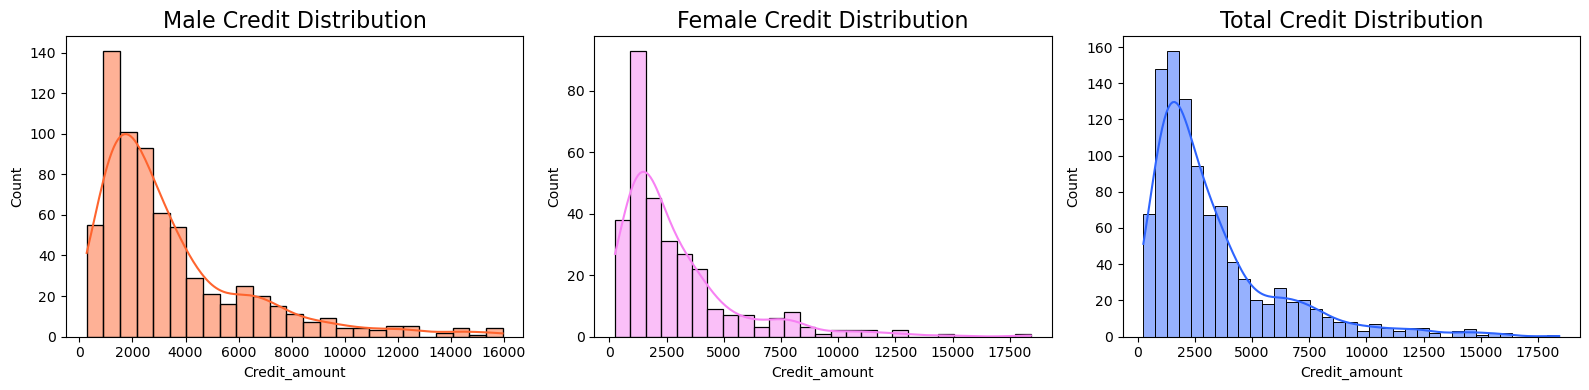

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

male_credit = df.loc[df["Sex"] == "male", "Credit_amount"]
female_credit = df.loc[df["Sex"] == "female", "Credit_amount"]
total_credit = df["Credit_amount"]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(male_credit, kde=True, ax=ax[0], color="#FE642E")
ax[0].set_title("Male Credit Distribution", fontsize=16)

sns.histplot(female_credit, kde=True, ax=ax[1], color="#F781F3")
ax[1].set_title("Female Credit Distribution", fontsize=16)

sns.histplot(total_credit, kde=True, ax=ax[2], color="#2E64FE")
ax[2].set_title("Total Credit Distribution", fontsize=16)

plt.tight_layout()
plt.show()

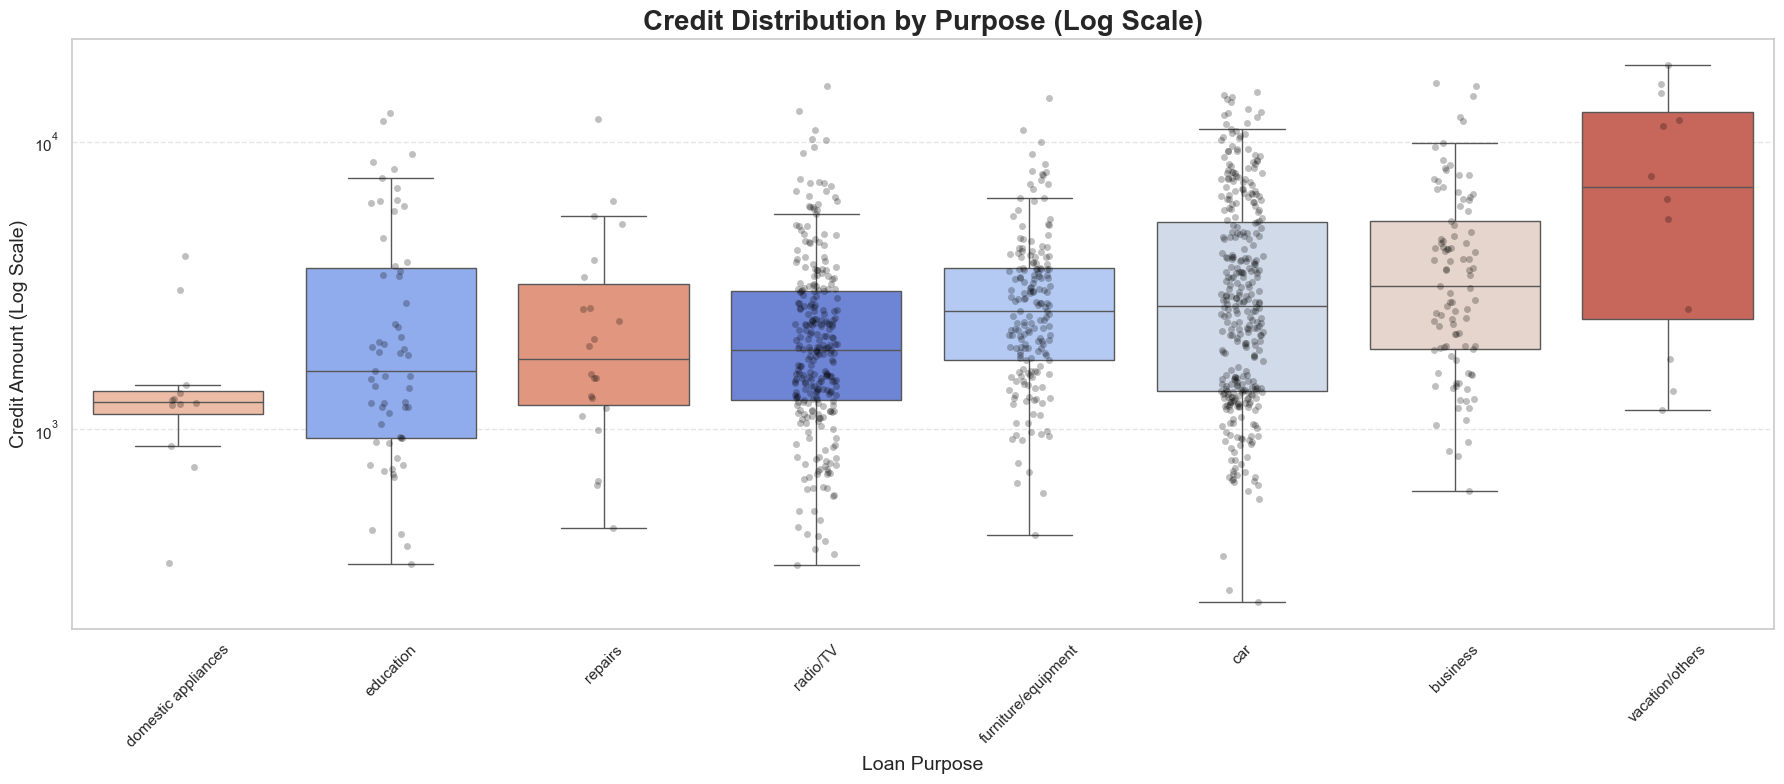

In [32]:


plt.figure(figsize=(18, 8))

# Sort by median (important insight)
order = df.groupby("Purpose")["Credit_amount"].median().sort_values().index

g = sns.boxplot(
    data=df,
    x="Purpose",
    y="Credit_amount",
    hue="Purpose",          # future-proof (no warning)
    order=order,
    palette="coolwarm",
    showfliers=False,
    legend=False
)

# Overlay real data points
sns.stripplot(
    data=df,
    x="Purpose",
    y="Credit_amount",
    order=order,
    color="black",
    alpha=0.25,
    jitter=True
)

# Log scale for skewed data
g.set_yscale("log")

# Titles & labels (clean, no emoji)
plt.title("Credit Distribution by Purpose (Log Scale)", fontsize=20, weight='bold')
plt.xlabel("Loan Purpose", fontsize=14)
plt.ylabel("Credit Amount (Log Scale)", fontsize=14)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [33]:
df["Sex"].value_counts()

Sex
male      690
female    310
Name: count, dtype: int64

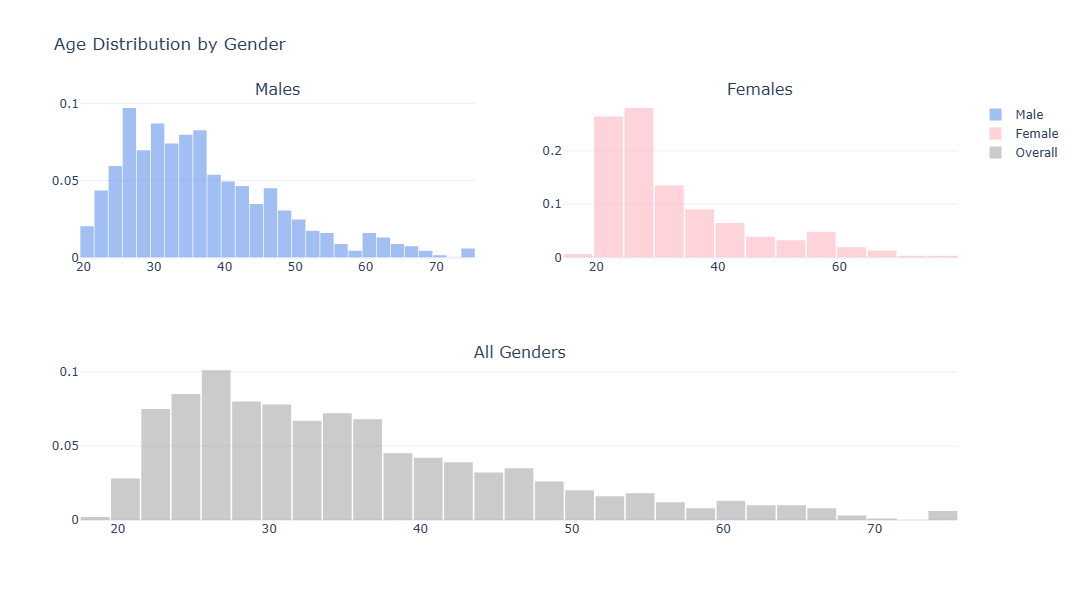

In [35]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data
male_age = df.loc[df['Sex'] == 'male', 'Age']
female_age = df.loc[df['Sex'] == 'female', 'Age']
all_age = df['Age']

# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{}, {}],
           [{"colspan": 2}, None]],
    subplot_titles=("Males", "Females", "All Genders")
)

# Male
fig.add_trace(
    go.Histogram(
        x=male_age,
        histnorm='probability',
        name="Male",
        marker=dict(color='rgba(100,149,237,0.6)')
    ),
    row=1, col=1
)

# Female
fig.add_trace(
    go.Histogram(
        x=female_age,
        histnorm='probability',
        name="Female",
        marker=dict(color='rgba(255,182,193,0.6)')
    ),
    row=1, col=2
)

# Overall
fig.add_trace(
    go.Histogram(
        x=all_age,
        histnorm='probability',
        name="Overall",
        marker=dict(color='rgba(169,169,169,0.6)')
    ),
    row=2, col=1
)

# Layout
fig.update_layout(
    title="Age Distribution by Gender",
    bargap=0.05,
    template="plotly_white",
    height=600
)

fig.show()

In [36]:
df["Purpose"].unique()
sex_purpose = pd.crosstab(df['Purpose'], df['Sex']).apply(lambda x: x/x.sum() * 100)
sex_purpose

Sex,female,male
Purpose,,
business,6.129032,11.304348
car,30.322581,35.217391
domestic appliances,1.935484,0.869565
education,7.741935,5.072464
furniture/equipment,23.870968,15.507246
radio/TV,27.419355,28.260870
repairs,1.612903,2.463768
vacation/others,0.967742,1.304348


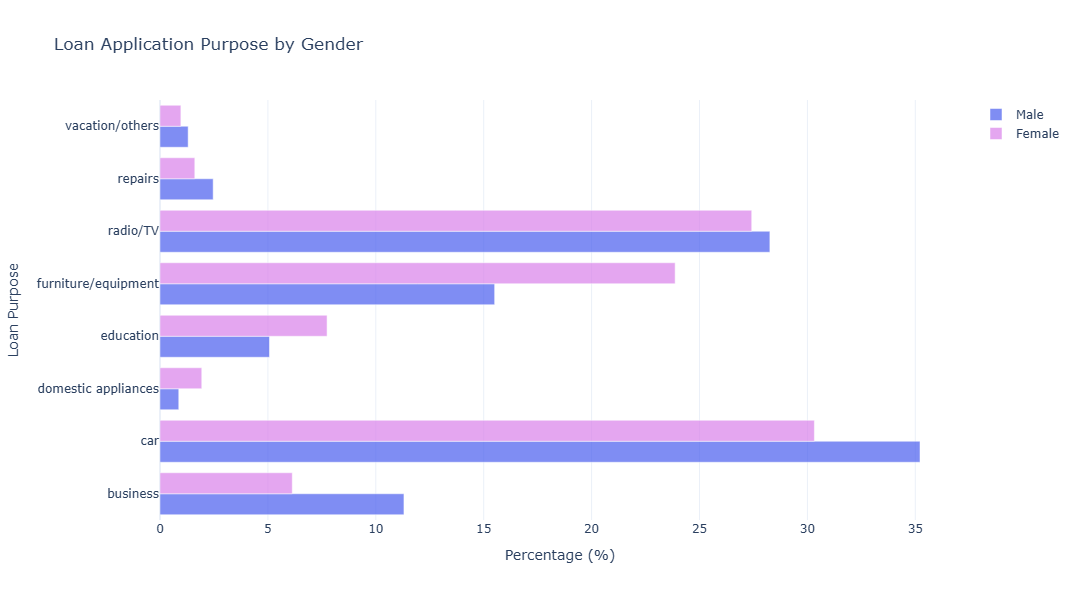

In [38]:
import plotly.graph_objects as go

# Categories
purposes = [
    'business', 'car', 'domestic appliances', 'education',
    'furniture/equipment', 'radio/TV', 'repairs', 'vacation/others'
]

# Values (no string conversion — keep numeric)
male_values = sex_purpose['male'].values
female_values = sex_purpose['female'].values

# Create figure
fig = go.Figure()

# Male bars
fig.add_trace(go.Bar(
    y=purposes,
    x=male_values,
    name='Male',
    orientation='h',
    marker=dict(color='rgba(72,92,238,0.7)')
))

# Female bars
fig.add_trace(go.Bar(
    y=purposes,
    x=female_values,
    name='Female',
    orientation='h',
    marker=dict(color='rgba(217,128,234,0.7)')
))

# Layout
fig.update_layout(
    title="Loan Application Purpose by Gender",
    xaxis_title="Percentage (%)",
    yaxis_title="Loan Purpose",
    barmode='group',   # 🔥 better than stack for comparison
    template="plotly_white",
    height=600
)

fig.show()

In [39]:
number_of_jobs = pd.crosstab(df["Job"], df["Sex"]).apply(lambda x: x/x.sum() * 100)
number_of_jobs

Sex,female,male
Job,,
0,3.870968,1.449275
1,20.645161,19.710145
2,63.548387,62.753623
3,11.935484,16.086957


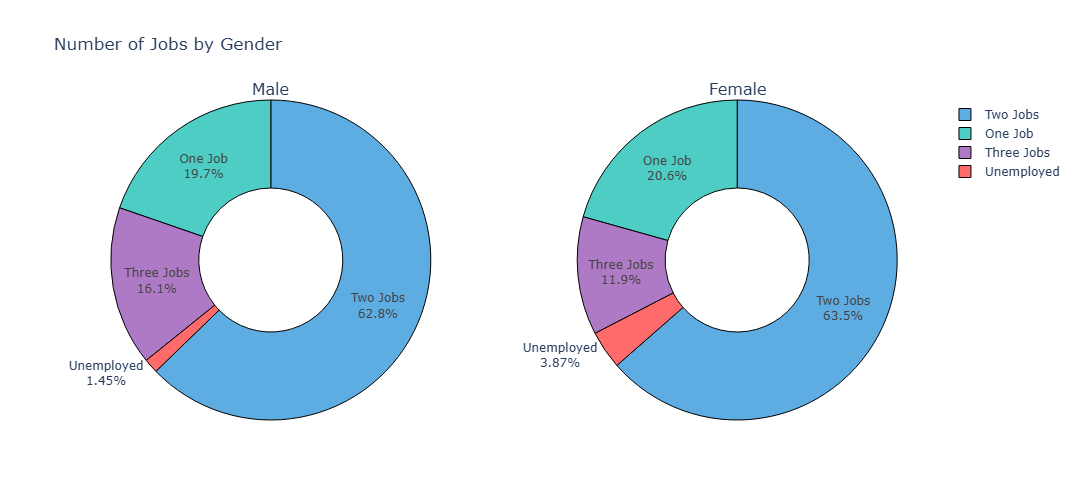

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Labels
labels = ["Unemployed", "One Job", "Two Jobs", "Three Jobs"]

# Keep values NUMERIC (no string conversion)
male_values = number_of_jobs["male"].values
female_values = number_of_jobs["female"].values

# Create subplot (2 donuts side by side)
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=["Male", "Female"]
)

# Male donut
fig.add_trace(
    go.Pie(
        labels=labels,
        values=male_values,
        name="Male",
        hole=0.45,
        marker=dict(
            colors=['#FF6B6B', '#4ECDC4', '#5DADE2', '#AF7AC5'],
            line=dict(color='black', width=1)
        ),
        textinfo='percent+label'
    ),
    row=1, col=1
)

# Female donut
fig.add_trace(
    go.Pie(
        labels=labels,
        values=female_values,
        name="Female",
        hole=0.45,
        marker=dict(
            colors=['#FF6B6B', '#4ECDC4', '#5DADE2', '#AF7AC5'],
            line=dict(color='black', width=1)
        ),
        textinfo='percent+label'
    ),
    row=1, col=2
)

# Layout
fig.update_layout(
    title="Number of Jobs by Gender",
    template="plotly_white",
    height=500
)

fig.show()

In [43]:
import numpy as np

# Create Age Groups (vectorized — fast & clean)
df['Age_Group'] = np.select(
    [
        (df['Age'] > 18) & (df['Age'] <= 29),
        (df['Age'] > 29) & (df['Age'] <= 40),
        (df['Age'] > 40) & (df['Age'] <= 55),
        (df['Age'] > 55)
    ],
    [
        'Young',
        'Young Adults',
        'Senior',
        'Elder'
    ],
    default='Unknown'
)

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit_amount,Duration,Purpose,Risk,Age_Group
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good,Elder
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,Young
2,2,49,male,1,own,little,NaN,2096,12,education,good,Senior
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Senior
4,4,53,male,2,free,little,little,4870,24,car,bad,Senior


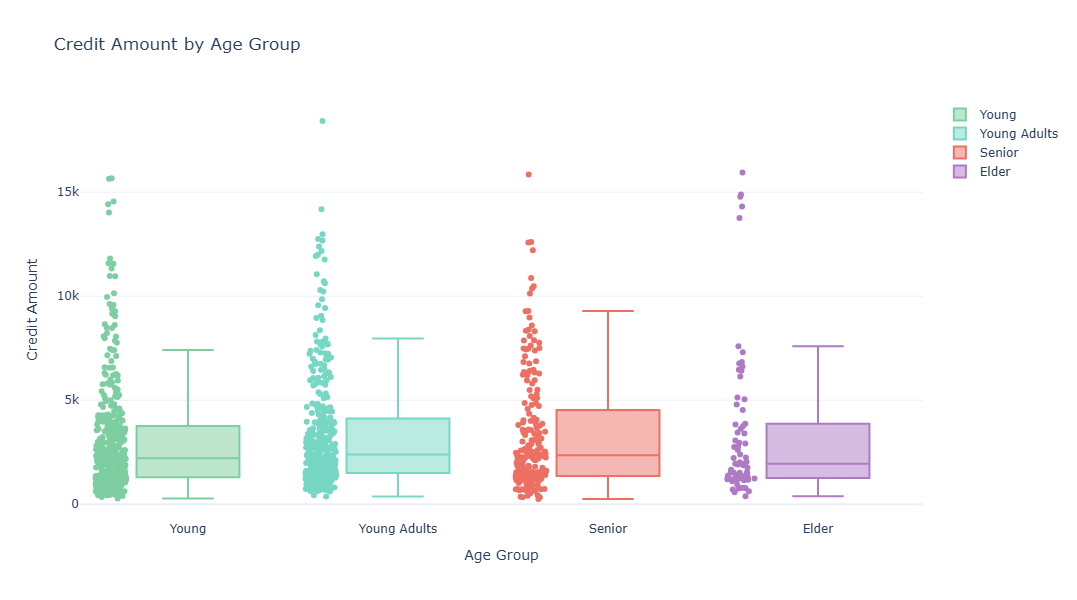

In [44]:
import plotly.graph_objects as go

# Create figure directly from dataframe (no manual lists needed)
fig = go.Figure()

fig.add_trace(go.Box(
    y=df.loc[df['Age_Group'] == 'Young', 'Credit_amount'],
    name="Young",
    boxpoints='all',
    jitter=0.3,
    pointpos=-1.5,
    marker_color='#7DCEA0'
))

fig.add_trace(go.Box(
    y=df.loc[df['Age_Group'] == 'Young Adults', 'Credit_amount'],
    name="Young Adults",
    boxpoints='all',
    jitter=0.3,
    pointpos=-1.5,
    marker_color='#76D7C4'
))

fig.add_trace(go.Box(
    y=df.loc[df['Age_Group'] == 'Senior', 'Credit_amount'],
    name="Senior",
    boxpoints='all',
    jitter=0.3,
    pointpos=-1.5,
    marker_color='#EC7063'
))

fig.add_trace(go.Box(
    y=df.loc[df['Age_Group'] == 'Elder', 'Credit_amount'],
    name="Elder",
    boxpoints='all',
    jitter=0.3,
    pointpos=-1.5,
    marker_color='#AF7AC5'
))

# Layout
fig.update_layout(
    title="Credit Amount by Age Group",
    xaxis_title="Age Group",
    yaxis_title="Credit Amount",
    template="plotly_white",
    height=600
)

fig.show()

In [45]:
good_credit_df = df[df['Risk'] == "good"]
bad_credit_df = df[df['Risk'] == "bad"]

good_credit_df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit_amount,Duration,Purpose,Risk,Age_Group
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good,Elder
2,2,49,male,1,own,little,NaN,2096,12,education,good,Senior
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Senior
5,5,35,male,1,free,NaN,NaN,9055,36,education,good,Young Adults
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good,Senior


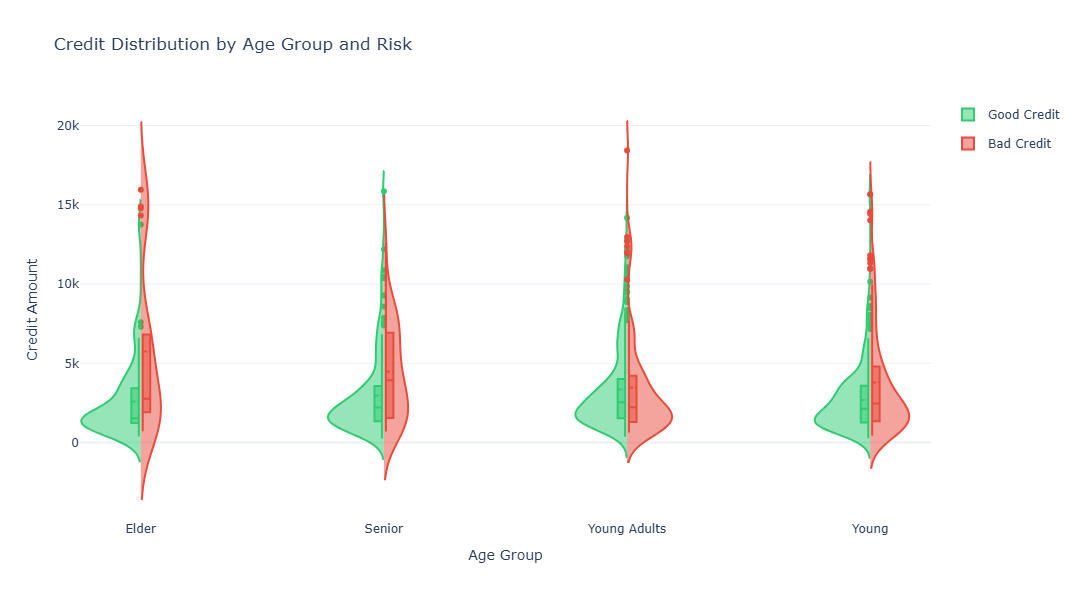

In [46]:
import plotly.graph_objects as go

fig = go.Figure()

# Good Credit
fig.add_trace(go.Violin(
    x=good_credit_df['Age_Group'],
    y=good_credit_df['Credit_amount'],
    name='Good Credit',
    legendgroup='Good',
    scalegroup='group',
    side='negative',
    box_visible=True,
    meanline_visible=True,
    line_color='#2ECC71'
))

# Bad Credit
fig.add_trace(go.Violin(
    x=bad_credit_df['Age_Group'],
    y=bad_credit_df['Credit_amount'],
    name='Bad Credit',
    legendgroup='Bad',
    scalegroup='group',
    side='positive',
    box_visible=True,
    meanline_visible=True,
    line_color='#E74C3C'
))

# Layout
fig.update_layout(
    title="Credit Distribution by Age Group and Risk",
    yaxis_title="Credit Amount",
    xaxis_title="Age Group",
    violinmode='overlay',
    template="plotly_white",
    height=600
)

fig.show()

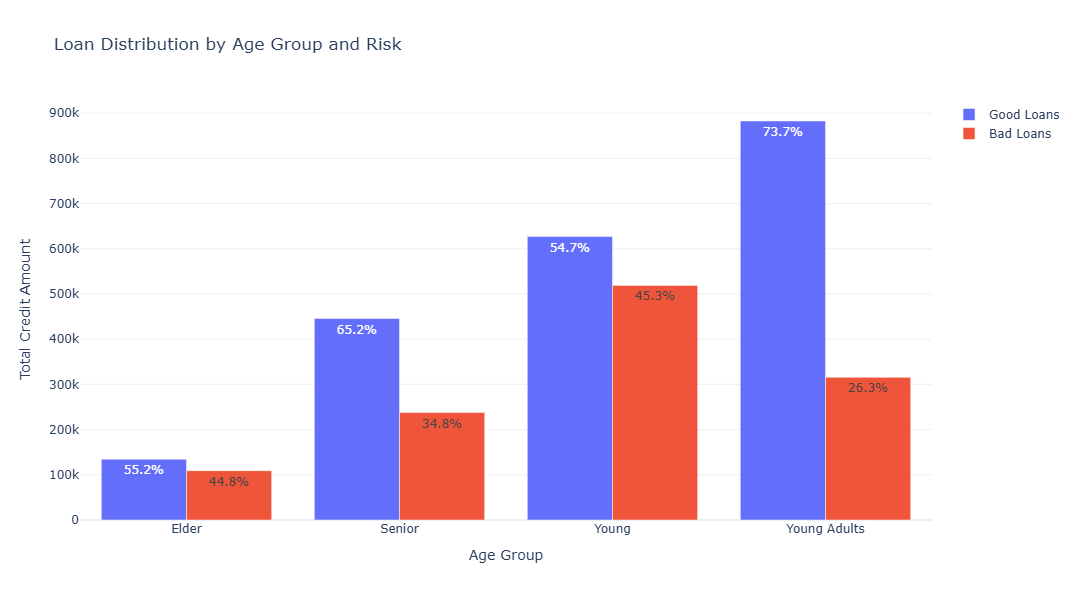

In [47]:
import pandas as pd
import plotly.graph_objects as go

# =========================
# 1. Aggregate Data
# =========================
grouped = df.groupby(['Age_Group', 'Risk'])['Credit_amount'].sum().reset_index()

# Pivot table
pivot = grouped.pivot(index='Age_Group', columns='Risk', values='Credit_amount').fillna(0)

# Calculate percentages
percent = pivot.div(pivot.sum(axis=1), axis=0) * 100

# =========================
# 2. Plot
# =========================
fig = go.Figure()

fig.add_trace(go.Bar(
    x=pivot.index,
    y=pivot['good'],
    name="Good Loans",
    text=[f"{p:.1f}%" for p in percent['good']],
    textposition='auto',
))

fig.add_trace(go.Bar(
    x=pivot.index,
    y=pivot['bad'],
    name="Bad Loans",
    text=[f"{p:.1f}%" for p in percent['bad']],
    textposition='auto',
))

# Layout
fig.update_layout(
    title="Loan Distribution by Age Group and Risk",
    xaxis_title="Age Group",
    yaxis_title="Total Credit Amount",
    barmode='group',
    template="plotly_white",
    height=600
)

fig.show()

In [48]:
# We have some missing value so we will just ignore the missing values in this analysis.
df["Checking account"].unique()
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit_amount', 'Duration', 'Purpose', 'Risk',
       'Age_Group'],
      dtype='object')

In [49]:
cross_checking = pd.crosstab(df['Risk'], df['Checking account']).apply(lambda x: x/x.sum() * 100)
decimals = pd.Series([2,2,2], index=['little', 'moderate', 'rich'])

cross_checking = cross_checking.round(decimals)
cross_checking

Checking account,little,moderate,rich
Risk,,,
bad,49.27,39.03,22.22
good,50.73,60.97,77.78


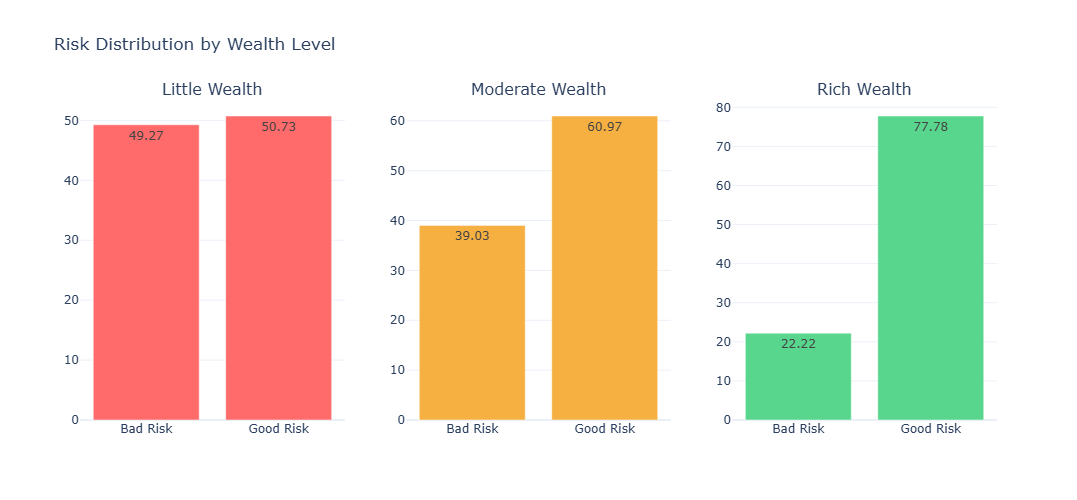

In [50]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Safer extraction (works even if order changes)
bad_little = cross_checking.loc['bad', 'little']
good_little = cross_checking.loc['good', 'little']

bad_moderate = cross_checking.loc['bad', 'moderate']
good_moderate = cross_checking.loc['good', 'moderate']

bad_rich = cross_checking.loc['bad', 'rich']
good_rich = cross_checking.loc['good', 'rich']

# Create subplots
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Little Wealth", "Moderate Wealth", "Rich Wealth")
)

# Little Wealth
fig.add_trace(go.Bar(
    x=['Bad Risk', 'Good Risk'],
    y=[bad_little, good_little],
    name="Little",
    marker_color='#FF6B6B',
    text=[bad_little, good_little],
    textposition='auto'
), row=1, col=1)

# Moderate Wealth
fig.add_trace(go.Bar(
    x=['Bad Risk', 'Good Risk'],
    y=[bad_moderate, good_moderate],
    name="Moderate",
    marker_color='#F5B041',
    text=[bad_moderate, good_moderate],
    textposition='auto'
), row=1, col=2)

# Rich Wealth
fig.add_trace(go.Bar(
    x=['Bad Risk', 'Good Risk'],
    y=[bad_rich, good_rich],
    name="Rich",
    marker_color='#58D68D',
    text=[bad_rich, good_rich],
    textposition='auto'
), row=1, col=3)

# Layout
fig.update_layout(
    title="Risk Distribution by Wealth Level",
    template="plotly_white",
    height=500,
    showlegend=False
)

fig.show()

In [51]:
df['Risk_int'] = np.nan
lst = [df]

for col in lst:
    col.loc[df['Risk'] == 'bad', 'Risk_int'] = 0 
    col.loc[df['Risk'] == 'good', 'Risk_int'] = 1
    
    
df['Risk_int'] = df['Risk_int'].astype(int)
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit_amount,Duration,Purpose,Risk,Age_Group,Risk_int
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good,Elder,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,Young,0
2,2,49,male,1,own,little,NaN,2096,12,education,good,Senior,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Senior,1
4,4,53,male,2,free,little,little,4870,24,car,bad,Senior,0


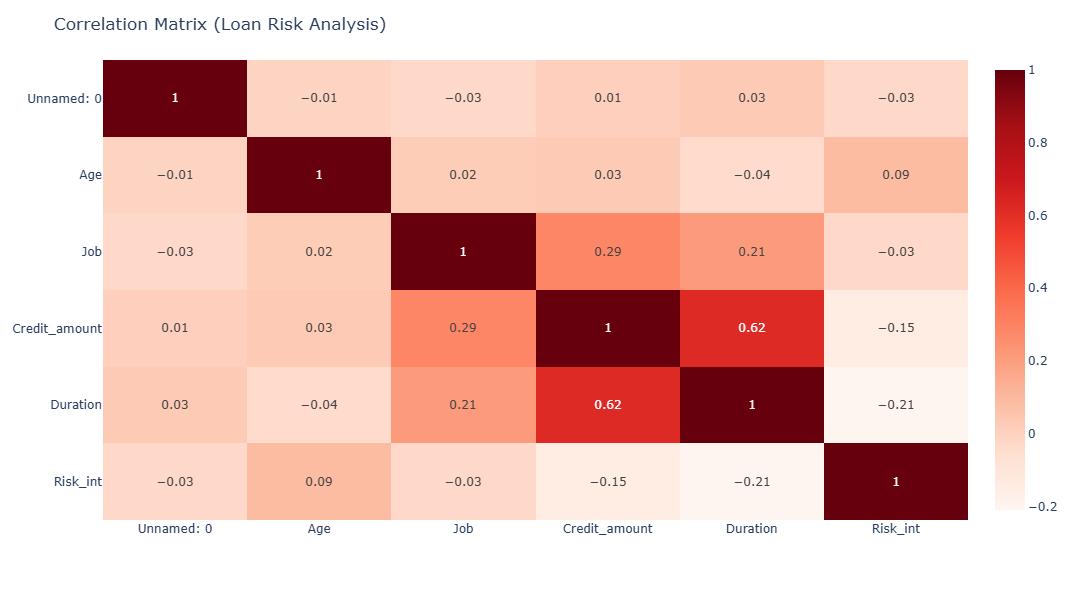

In [53]:
import plotly.express as px
import numpy as np

# =========================
# 1. Correlation Matrix
# =========================
corr = df.corr(numeric_only=True).round(2)

# =========================
# 2. Heatmap
# =========================
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="Reds"
)

# Layout
fig.update_layout(
    title="Correlation Matrix (Loan Risk Analysis)",
    height=600
)

fig.show()

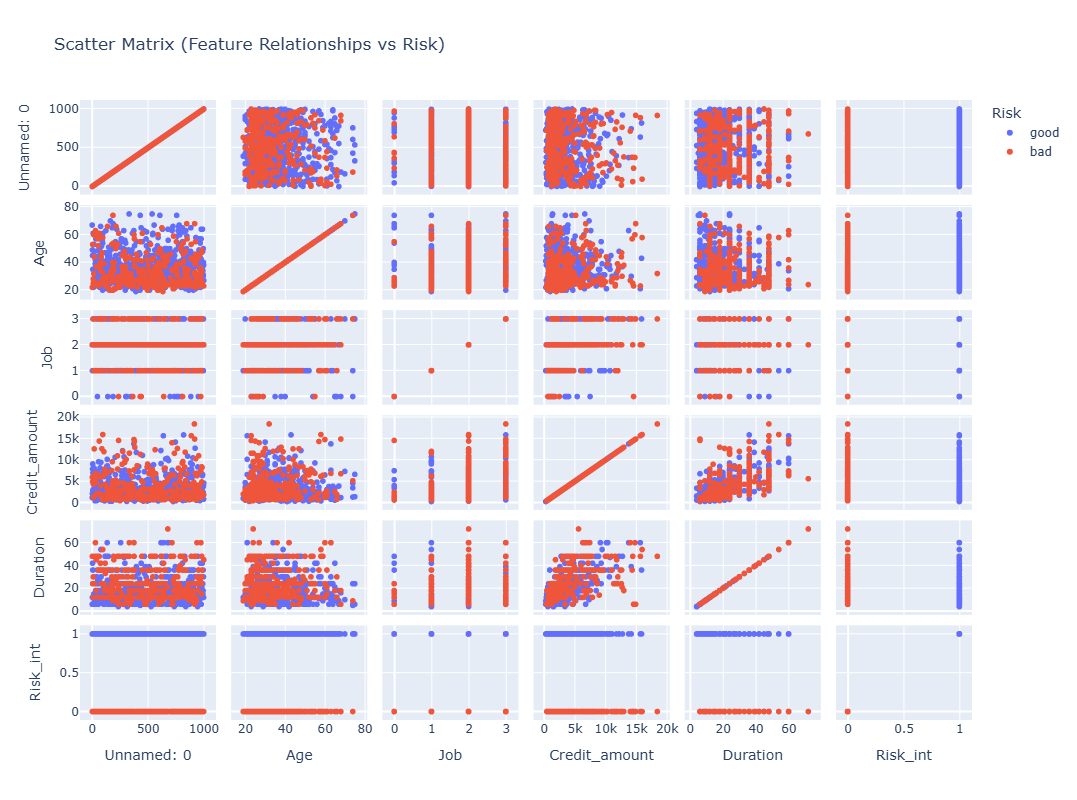

In [54]:
import plotly.express as px

# =========================
# 1. Select Numeric Columns
# =========================
numeric_df = df.select_dtypes(include='number')

# Add Risk separately (for coloring)
numeric_df['Risk'] = df['Risk']

# =========================
# 2. Scatter Matrix
# =========================
fig = px.scatter_matrix(
    numeric_df,
    dimensions=numeric_df.columns[:-1],  # exclude Risk from axes
    color='Risk',
    title="Scatter Matrix (Feature Relationships vs Risk)",
    height=800
)

fig.update_traces(diagonal_visible=True)

fig.show()

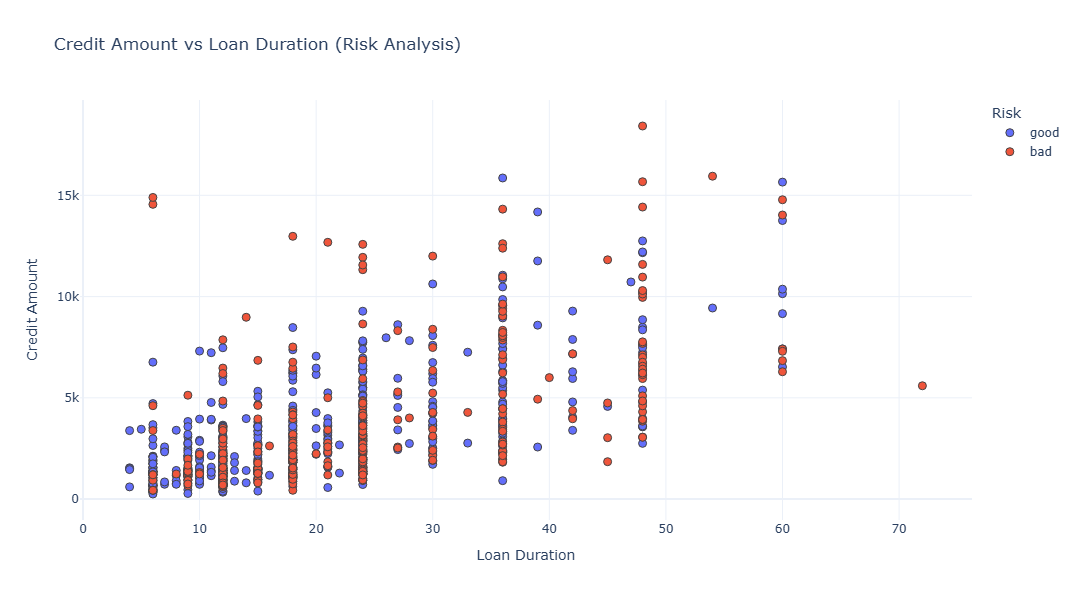

In [55]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Duration",
    y="Credit_amount",
    color="Risk",
    title="Credit Amount vs Loan Duration (Risk Analysis)",
    labels={
        "Duration": "Loan Duration",
        "Credit_amount": "Credit Amount"
    },
    height=600
)

fig.update_traces(marker=dict(size=8, line=dict(width=1)))

fig.update_layout(template="plotly_white")

fig.show()

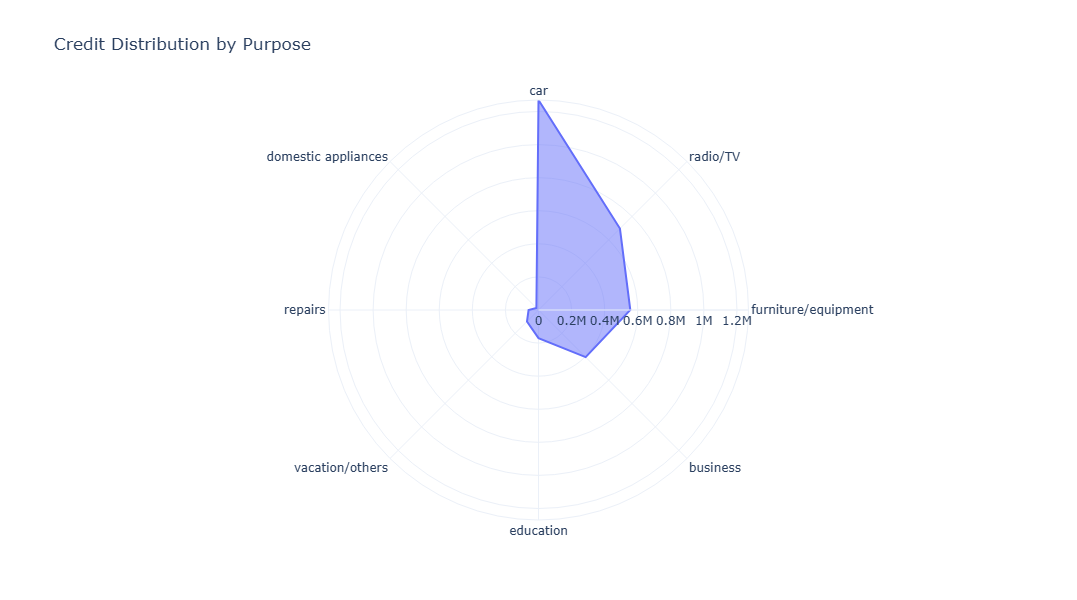

In [58]:
import plotly.express as px

# =========================
# 1. Aggregate Data
# =========================
purpose_df = (
    df.groupby("Purpose")["Credit_amount"]
    .sum()
    .reset_index()
    .sort_values(by="Credit_amount", ascending=False)
)

# =========================
# 2. Radar Chart
# =========================
fig = px.line_polar(
    purpose_df,
    r="Credit_amount",
    theta="Purpose",
    line_close=True,
    title="Credit Distribution by Purpose"
)

fig.update_traces(fill='toself')

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

In [59]:
df['Purpose'].unique()

cross_purpose = pd.crosstab(df['Purpose'], df['Risk']).apply(lambda x: x/x.sum() * 100)
cross_purpose = cross_purpose.round(decimals=2)
cross_purpose.sort_values(by=['bad'])

Risk,bad,good
Purpose,,
domestic appliances,1.33,1.14
vacation/others,1.67,1.00
repairs,2.67,2.00
education,7.67,5.14
business,11.33,9.00
furniture/equipment,19.33,17.57
radio/TV,20.67,31.14
car,35.33,33.00


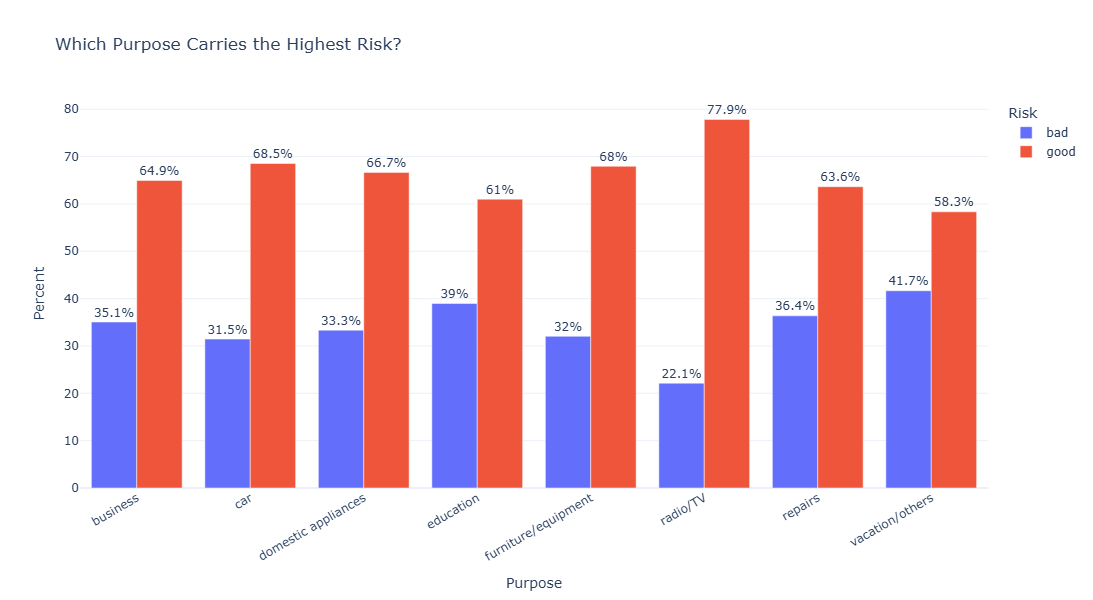

In [60]:
import plotly.express as px

# =========================
# 1. Create Proper Table
# =========================
purpose_risk = (
    df.groupby(['Purpose', 'Risk'])
    .size()
    .reset_index(name='Count')
)

# Convert to percentage
purpose_total = purpose_risk.groupby('Purpose')['Count'].transform('sum')
purpose_risk['Percent'] = (purpose_risk['Count'] / purpose_total) * 100

# =========================
# 2. Plot
# =========================
fig = px.bar(
    purpose_risk,
    x='Purpose',
    y='Percent',
    color='Risk',
    barmode='group',
    text=purpose_risk['Percent'].round(1),
    title="Which Purpose Carries the Highest Risk?"
)

fig.update_traces(texttemplate='%{text}%', textposition='outside')

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-30,
    height=600
)

fig.show()

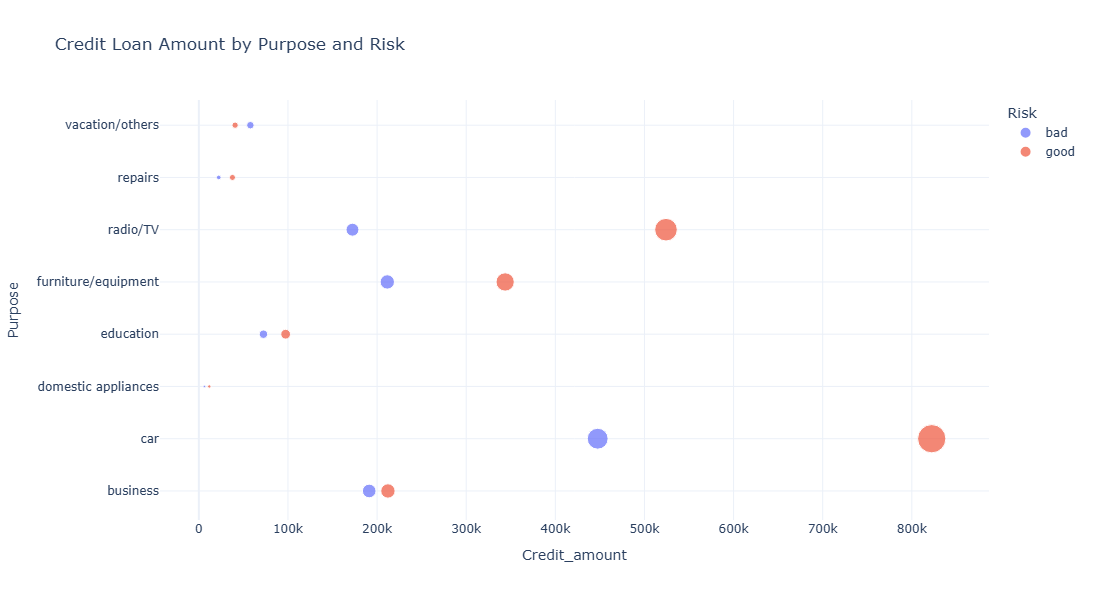

In [61]:
import plotly.express as px

# =========================
# 1. Aggregate Data
# =========================
cross_credit = (
    df.groupby(['Purpose', 'Risk'])['Credit_amount']
    .sum()
    .reset_index()
)

# =========================
# 2. Dot Plot
# =========================
fig = px.scatter(
    cross_credit,
    x="Credit_amount",
    y="Purpose",
    color="Risk",
    size="Credit_amount",
    title="Credit Loan Amount by Purpose and Risk",
    height=600
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

In [65]:
df.isnull().sum().sort_values(ascending=False)

Checking account    394
Saving accounts     183
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Credit_amount         0
Duration              0
Purpose               0
Risk                  0
Age_Group             0
Risk_int              0
dtype: int64

In [66]:
df.drop(['Checking account', 'Saving accounts'], axis=1, inplace=True)

In [67]:
df.isnull().sum().sort_values(ascending=False)

Unnamed: 0       0
Age              0
Sex              0
Job              0
Housing          0
Credit_amount    0
Duration         0
Purpose          0
Risk             0
Age_Group        0
Risk_int         0
dtype: int64

In [71]:
from sklearn.model_selection import StratifiedShuffleSplit

# =========================
# 1. Stratified Split
# =========================
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(df,df["Risk"]):
    strat_train = df.iloc[train_idx]
    strat_test = df.iloc[test_idx]

# =========================
# 2. Check Distribution
# =========================
print("Full Dataset:")
print(df["Risk"].value_counts(normalize=True))

print("\nTrain Set:")
print(strat_train["Risk"].value_counts(normalize=True))

print("\nTest Set:")
print(strat_test["Risk"].value_counts(normalize=True))

Full Dataset:
Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

Train Set:
Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

Test Set:
Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64


In [73]:
# Have our new train and test data
train = strat_train
test = strat_test


# Our features
X_train = train.drop('Risk', axis=1)
X_test = test.drop('Risk', axis=1)

# Our Labels we will use them later
y_train = train["Risk"]
y_test = test["Risk"]

In [75]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# =========================
# 1. Separate Features
# =========================
X = strat_train.drop("Risk", axis=1)
y = strat_train["Risk"]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# =========================
# 2. Preprocessor (IMPORTANT)
# =========================
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# =========================
# 3. Pipeline
# =========================
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# =========================
# 4. Train Model
# =========================
pipeline.fit(X, y)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [76]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# =========================
# 1. Your Selector Class
# =========================
class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.attribute_names].values

# =========================
# 2. Column Separation
# =========================
X = strat_train.drop("Risk", axis=1)
y = strat_train["Risk"]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# =========================
# 3. Numerical Pipeline
# =========================
num_pipeline = Pipeline([
    ('selector', DataFrameSelector(num_cols)),
    ('scaler', StandardScaler())
])

# =========================
# 4. Categorical Pipeline
# =========================
cat_pipeline = Pipeline([
    ('selector', DataFrameSelector(cat_cols)),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# =========================
# 5. Combine Pipelines
# =========================
full_pipeline = FeatureUnion(transformer_list=[
    ('num_pipeline', num_pipeline),
    ('cat_pipeline', cat_pipeline)
])

# =========================
# 6. Final Model Pipeline
# =========================
final_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# =========================
# 7. Train Model
# =========================
final_pipeline.fit(X, y)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('num_pipeline', ...), ('cat_pipeline', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,attribute_names,"['Unnamed: 0', 'Age', ...]"
,copy,True


In [80]:
from sklearn.preprocessing import LabelEncoder

encode = LabelEncoder()
y_train_scaled = encode.fit_transform(y_train)
y_test_scaled = encode.fit_transform(y_test)


In [83]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Create some sample data (replace this with your actual data)
X = np.random.rand(100, 4)  # Example feature matrix
y = np.random.randint(0, 2, 100)  # Example binary target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Parameter grid (optimized)
param_grid = [
    {'kernel': ['linear'], 'C': [0.75, 0.85, 0.95, 1]},
    {'kernel': ['rbf'], 'C': [0.75, 0.85, 0.95, 1], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.75, 0.85, 0.95, 1], 'degree': [3, 4, 5]},
    {'kernel': ['sigmoid'], 'C': [0.75, 0.85, 0.95, 1]}
]

svc_clf = SVC(random_state=42)

grid_search_cv = GridSearchCV(
    svc_clf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# ✅ Use original y_train (NOT scaled)
grid_search_cv.fit(X_train_scaled, y_train)

,estimator,SVC(random_state=42)
,param_grid,"[{'C': [0.75, 0.85, ...], 'kernel': ['linear']}, {'C': [0.75, 0.85, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}, ...]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.75


In [84]:
grid_search_cv.best_estimator_

,C,0.75
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [85]:
grid_search_cv.best_params_

{'C': 0.75, 'gamma': 'scale', 'kernel': 'rbf'}

In [87]:
from sklearn.metrics import classification_report

best_model = grid_search_cv.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.86      0.57         7
           1       0.83      0.38      0.53        13

    accuracy                           0.55        20
   macro avg       0.63      0.62      0.55        20
weighted avg       0.69      0.55      0.54        20



In [90]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svc_clf.predict(X_test_scaled)

print("Accuracy:", svc_clf.score(X_test_scaled, y_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.55

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.86      0.57         7
           1       0.83      0.38      0.53        13

    accuracy                           0.55        20
   macro avg       0.63      0.62      0.55        20
weighted avg       0.69      0.55      0.54        20


Confusion Matrix:
 [[6 1]
 [8 5]]


In [104]:
X_train = strat_train.drop("Risk", axis=1)
y_train = strat_train["Risk"]

X_test = strat_test.drop("Risk", axis=1)
y_test = strat_test["Risk"]

In [108]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# First, ensure X_train_scaled and y_train have the same number of samples
# Check their shapes
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")

# Make sure they have the same number of samples (rows)
# Option 1: If you need to use all data, find out why they're different sizes
# Option 2: Slice the larger dataset to match the smaller one
if len(X_train_scaled) > len(y_train):
    X_train_scaled = X_train_scaled[:len(y_train)]
elif len(y_train) > len(X_train_scaled):
    y_train = y_train[:len(X_train_scaled)]

# Now they should have the same number of samples
print(f"After adjustment - X_train_scaled shape: {X_train_scaled.shape}")
print(f"After adjustment - y_train shape: {y_train.shape}")

# Now run the cross-validation
svc_clf = SVC(kernel='rbf', C=1, random_state=42)
scores = cross_val_score(svc_clf, X_train_scaled, y_train, cv=5)

print("Scores:", scores)
print("Mean:", scores.mean())

X_train_scaled shape: (80, 4)
y_train shape: (800,)
After adjustment - X_train_scaled shape: (80, 4)
After adjustment - y_train shape: (80,)
Scores: [0.6875 0.75   0.6875 0.6875 0.6875]
Mean: 0.7
